
# Proceso ETL (Extracción, Transformación y Carga) — **Alerta Ciudadana**

Este notebook implementa la fase ETL con los pasos acordados:

1. **Importación de librerías**  
2. **Carga de datos** (desde MySQL usando tu archivo `alertaCiudadana.sql` o la estructura `*.sql` + procedimientos para poblar datos de prueba)  
3. **Creación del DataFrame** base  
4. **Análisis Exploratorio de Datos (EDA)**  
5. **Limpieza de Datos**  
6. **Visualización de Datos** (2 a 5 gráficas)  
7. **Conclusión de la fase**

> Si no tienes datos cargados, el notebook incluye celdas para **crear la BD** con la estructura y **generar datos de prueba** mediante *stored procedures*.


## 1) Importación de Librerías

In [49]:

# Si te falta alguna librería, instala con:
# pip install pandas numpy sqlalchemy pymysql matplotlib

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from sqlalchemy import create_engine, text
from datetime import datetime


## 2) Configuración y Conexión a MySQL

In [23]:

# 👉 Ajusta estos valores a tu entorno local
MYSQL_USER = os.getenv("MYSQL_USER", "root")
MYSQL_PASS = os.getenv("MYSQL_PASS", "1234")
MYSQL_HOST = os.getenv("MYSQL_HOST", "localhost")
MYSQL_PORT = int(os.getenv("MYSQL_PORT", "3309"))
MYSQL_DB   = os.getenv("MYSQL_DB", "bd_alertaciudadana")

# Ruta local al archivo con la estructura o datos
# - Usa tu archivo con datos reales: 'alertaCiudadana.sql'
# - O usa la estructura: 'alertaCiudadana_onlyStructure.sql'
SQL_FILE_PATH = os.getenv("SQL_FILE_PATH", "alertaCiudadana.sql")

# Cadena de conexión
engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASS}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DB}", echo=False, future=True)
print("Conexión lista (pendiente abrir/usar).")


Conexión lista (pendiente abrir/usar).


## (Opcional) Crear Base de Datos y Cargar Estructura/Datos


Ejecuta **una sola vez** si necesitas crear la base de datos o cargar datos desde tu `alertaCiudadana.sql`.

- Si tu archivo `.sql` contiene **estructura + datos**, con esto será suficiente.
- Si solo contiene **estructura**, después ejecuta la sección de **Generación de Datos de Prueba**.


In [ ]:

# Ejecutar un archivo .sql largo en MySQL desde Python.
# Nota: algunos dumps requieren que primero crees la BD fuera de SQLAlchemy (CREATE DATABASE).
# Si tu archivo incluye 'CREATE DATABASE' y 'USE', puedes ejecutar directamente.

def run_sql_file(engine, sql_path):
    from sqlalchemy import text
    with open(sql_path, "r", encoding="utf-8") as f:
        sql_script = f.read()
    # Divide en statements por ';' respetando el caso más simple
    # (para dumps complejos, se recomienda usar el cliente de MySQL).
    statements = [s.strip() for s in sql_script.split(';') if s.strip()]
    with engine.begin() as conn:
        for stmt in statements:
            try:
                conn.execute(text(stmt))
            except Exception as e:
                # Muchos dumps tienen comandos específicos del cliente; ignoramos los que fallen inofensivamente.
                print("[AVISO] No se pudo ejecutar un statement (continuando):", str(e)[:180])

# Descomenta si quieres ejecutar el SQL automáticamente
run_sql_file(engine, SQL_FILE_PATH)
print("Carga de SQL finalizada.")

## (Opcional) Generación de Datos de Prueba


Si cargaste únicamente la **estructura**, usa estas celdas para poblar la BD con datos sintéticos usando los *stored procedures*:

- `sp_insertar_categorias_aleatorias()`
- `sp_crear_usuarios_aleatorios(cantidad)`
- `sp_insertar_incidentes_aleatorios(cantidad)`
- `sp_insertar_comentarios_aleatorios(cantidad)`
- (o `sp_generar_datos_prueba(usuarios, incidentes, comentarios)`)


In [ ]:
with engine.begin() as conn:
    # Inserta categorías si no existen
    conn.execute(text("CALL sp_insertar_categorias_aleatorias()"))
    # Genera 200 usuarios, 500 incidentes y 1000 comentarios (ajusta a tu gusto)
    conn.execute(text("CALL sp_crear_usuarios_aleatorios(:n)"), {"n": 200})
    conn.execute(text("CALL sp_insertar_incidentes_aleatorios(:n)"), {"n": 500})
    conn.execute(text("CALL sp_insertar_comentarios_aleatorios(:n)"), {"n": 1000})
print("Datos de prueba generados.")

## 3) Extracción de Datos (E)

In [25]:

def read_df(query: str) -> pd.DataFrame:
    return pd.read_sql_query(text(query), engine)

df_usuarios    = read_df("SELECT * FROM usuarios")
df_categorias  = read_df("SELECT * FROM categorias")
df_incidentes  = read_df("SELECT * FROM incidentes")
df_comentarios = read_df("SELECT * FROM comentarios")

print("Usuarios:", df_usuarios.shape, "| Categorías:", df_categorias.shape, "| Incidentes:", df_incidentes.shape, "| Comentarios:", df_comentarios.shape)


Usuarios: (1001000, 6) | Categorías: (7, 3) | Incidentes: (1001000, 10) | Comentarios: (1001000, 5)


## 4) Creación del DataFrame base

In [26]:

# Unir incidentes con usuarios y categorías
df = (
    df_incidentes
    .merge(df_usuarios[['id','nombre','rol']], left_on='usuario_id', right_on='id', how='left', suffixes=('', '_usuario'))
    .merge(df_categorias[['id','nombre']], left_on='categoria_id', right_on='id', how='left', suffixes=('', '_categoria'))
    .rename(columns={'nombre':'usuario_nombre', 'nombre_categoria':'categoria_nombre'})
)

# Contar comentarios por incidente
comentarios_count = df_comentarios.groupby('incidente_id')['id'].count().rename('num_comentarios').reset_index()
df = df.merge(comentarios_count, left_on='id', right_on='incidente_id', how='left')
df['num_comentarios'] = df['num_comentarios'].fillna(0).astype(int)

# Limpieza de columnas duplicadas de merges
cols_drop = [c for c in ['id_usuario','id_categoria','incidente_id'] if c in df.columns]
df.drop(columns=cols_drop, inplace=True)

df.head()


,id,titulo,descripcion,imagen,latitud,longitud,estado,fecha_reporte,usuario_id,categoria_id,usuario_nombre,rol,categoria_nombre,num_comentarios
0,1,Falla en servicios públicos,Se presentó un corte de energía en la zona.,/img/incidente930.jpg,20.0535,-101.2850,descartado,2025-08-07 20:17:45,902,4,Roberto,ciudadano,Servicios públicos,1
1,2,Falla en servicios públicos,Se presentó un corte de energía en la zona.,/img/incidente725.jpg,19.3995,-100.7210,atendido,2025-08-01 20:17:45,798,4,Mateo,ciudadano,Servicios públicos,0
2,3,Reporte de seguridad pública,Vecinos reportan actividad inusual en la calle.,/img/incidente488.jpg,20.0304,-98.8305,en_revision,2025-08-12 20:17:45,304,1,Santiago,ciudadano,Seguridad pública,1
3,4,Incidente ambiental,Se detectó quema de pasto en la colonia.,/img/incidente592.jpg,20.3664,-99.0906,pendiente,2025-07-30 20:17:45,519,6,Carolina,ciudadano,Medio ambiente,2
4,5,Incidente ambiental,Se detectó quema de pasto en la colonia.,/img/incidente665.jpg,21.4933,-101.3300,pendiente,2025-07-29 20:17:45,531,6,Fernando,ciudadano,Medio ambiente,4


## 5) Análisis Exploratorio de Datos (EDA)

In [27]:

display(df.head(10))
display(df.describe(include='all').transpose())
display(df.isna().sum())


,id,titulo,descripcion,imagen,latitud,longitud,estado,fecha_reporte,usuario_id,categoria_id,usuario_nombre,rol,categoria_nombre,num_comentarios
0,1,Falla en servicios públicos,Se presentó un corte de energía en la zona.,/img/incidente930.jpg,20.0535,-101.2850,descartado,2025-08-07 20:17:45,902,4,Roberto,ciudadano,Servicios públicos,1
1,2,Falla en servicios públicos,Se presentó un corte de energía en la zona.,/img/incidente725.jpg,19.3995,-100.7210,atendido,2025-08-01 20:17:45,798,4,Mateo,ciudadano,Servicios públicos,0
2,3,Reporte de seguridad pública,Vecinos reportan actividad inusual en la calle.,/img/incidente488.jpg,20.0304,-98.8305,en_revision,2025-08-12 20:17:45,304,1,Santiago,ciudadano,Seguridad pública,1
3,4,Incidente ambiental,Se detectó quema de pasto en la colonia.,/img/incidente592.jpg,20.3664,-99.0906,pendiente,2025-07-30 20:17:45,519,6,Carolina,ciudadano,Medio ambiente,2
4,5,Incidente ambiental,Se detectó quema de pasto en la colonia.,/img/incidente665.jpg,21.4933,-101.3300,pendiente,2025-07-29 20:17:45,531,6,Fernando,ciudadano,Medio ambiente,4
5,6,Reporte de seguridad pública,Se observó una situación sospechosa en la zona.,/img/incidente198.jpg,21.2907,-99.4602,en_revision,2025-08-09 20:17:45,963,1,Susana,ciudadano,Seguridad pública,3
6,7,Falla en servicios públicos,El alumbrado público no está funcionando.,/img/incidente395.jpg,19.4074,-100.7500,atendido,2025-08-04 20:17:45,361,4,Pedro,ciudadano,Servicios públicos,1
7,8,Falla en servicios públicos,No hay servicio de agua desde hace horas.,/img/incidente583.jpg,24.8990,-100.6570,descartado,2025-07-19 20:17:45,64,4,Victoria,ciudadano,Servicios públicos,1
8,9,Reporte de ruido vecinal,Se escuchan constantes fiestas en la calle.,/img/incidente548.jpg,19.9100,-101.0830,pendiente,2025-08-09 20:17:45,877,5,Carlos,ciudadano,Ruido o molestias vecinales,3
9,10,Reporte de ruido vecinal,Reportan música muy fuerte a altas horas.,/img/incidente59.jpg,21.9553,-99.6908,descartado,2025-07-19 20:17:45,914,5,Regina,ciudadano,Ruido o molestias vecinales,1


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,1001000.0,NaN,NaN,NaN,500500.5,1.0,250250.75,500500.5,750750.25,1001000.0,288963.954068
titulo,1001000,7,Reporte de seguridad pública,143658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion,1001000,21,Se requiere presencia de seguridad en el área.,48200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imagen,1001000,1000,/img/incidente490.jpg,1108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitud,1001000.0,NaN,NaN,NaN,22.001303,19.0,20.5017,22.0009,23.5011,25.0,1.731515
longitud,1001000.0,NaN,NaN,NaN,-98.001807,-102.0,-99.999525,-98.0025,-96.0042,-94.0,2.308618
estado,1001000,4,pendiente,250993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_reporte,1001000,NaN,NaN,NaN,2025-08-02 08:12:05.001932288,2025-07-18 20:17:45,2025-07-25 20:25:47,2025-08-01 20:27:48,2025-08-09 20:25:46,2025-08-16 20:27:53,NaN
usuario_id,1001000.0,NaN,NaN,NaN,500442.960472,1.0,250188.75,500610.0,750999.25,1000999.0,289137.82018
categoria_id,1001000.0,NaN,NaN,NaN,3.99629,1.0,2.0,4.0,6.0,7.0,2.000826


id                  0
titulo              0
descripcion         0
imagen              0
latitud             0
longitud            0
estado              0
fecha_reporte       0
usuario_id          0
categoria_id        0
usuario_nombre      0
rol                 0
categoria_nombre    0
num_comentarios     0
dtype: int64

## 6) Limpieza de Datos

In [28]:

# Ejemplos de reglas básicas de limpieza

# 1) Fechas nulas -> imputar con fecha_reporte mínima/mediana
if 'fecha_reporte' in df.columns:
    if df['fecha_reporte'].isna().any():
        med = pd.to_datetime(df['fecha_reporte']).median()
        df['fecha_reporte'] = pd.to_datetime(df['fecha_reporte']).fillna(med)

# 2) Estados válidos
if 'estado' in df.columns:
    estados_validos = {'pendiente','en_revision','atendido','descartado'}
    df['estado'] = df['estado'].where(df['estado'].isin(estados_validos), 'pendiente')

# 3) Lat/Lon dentro de rangos razonables (Mx aprox: lat 14–33, lon -118 a -86)
if {'latitud','longitud'}.issubset(df.columns):
    df['latitud']  = df['latitud'].clip(14, 33)
    df['longitud'] = df['longitud'].clip(-118, -86)

# 4) Duplicados por (titulo, descripcion, usuario_id, fecha_reporte)
before = len(df)
df.drop_duplicates(subset=['titulo','descripcion','usuario_id','fecha_reporte'], inplace=True)
after = len(df)
print(f"Duplicados eliminados: {before - after}")


Duplicados eliminados: 40


## 7) Visualización de Datos (2 a 5 gráficas)

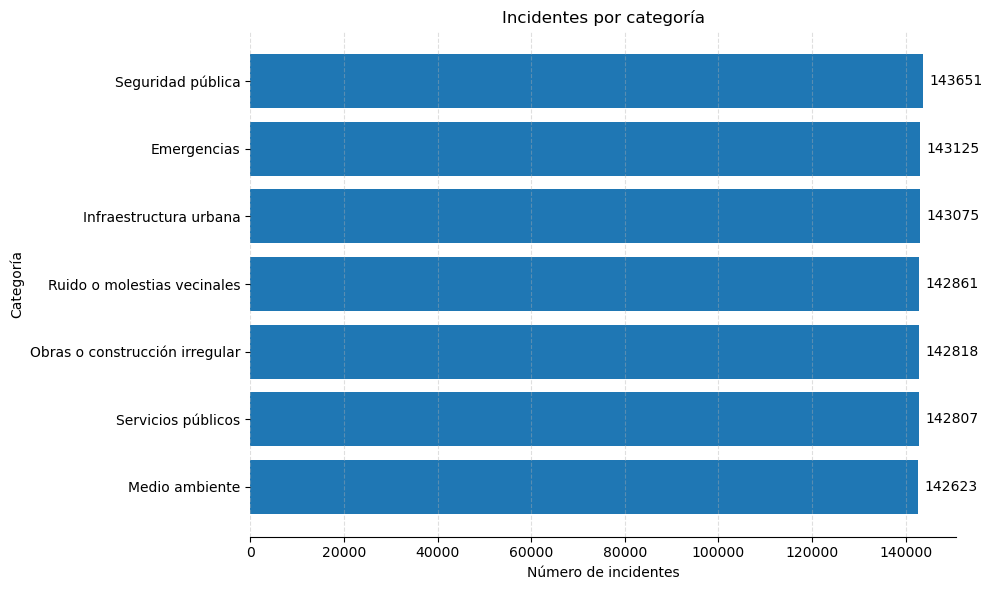

In [44]:
# Unimos para quedarnos con el nombre de la categoría y contamos
df_cat = (
    df.merge(
        df_categorias[['id', 'nombre']].rename(columns={'id':'categoria_id','nombre':'categoria'}),
        on='categoria_id', how='left'
    )
)
df_cat['categoria'] = df_cat['categoria'].fillna('Desconocida')

cat_counts = df_cat['categoria'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_counts.index, cat_counts.values)

# Título y ejes
ax.set_title("Incidentes por categoría")
ax.set_xlabel("Número de incidentes")
ax.set_ylabel("Categoría")

# Etiquetas con el valor al final de cada barra
max_val = cat_counts.values.max() if len(cat_counts) else 0
for i, v in enumerate(cat_counts.values):
    ax.text(v + max_val*0.01, i, str(v), va='center')

# Grid sutil, limpieza de spines
ax.grid(axis='x', linestyle='--', alpha=0.4)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

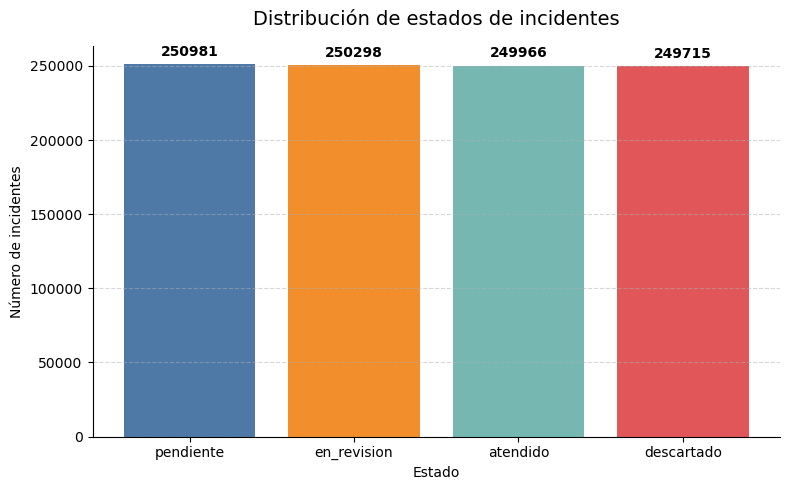

In [40]:
# Contar incidentes por estado, ordenado
state_counts = df['estado'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(state_counts.index, state_counts.values, color=['#4e79a7','#f28e2b','#76b7b2','#e15759'])

# Títulos y etiquetas de ejes
ax.set_title("Distribución de estados de incidentes", fontsize=14, pad=15)
ax.set_xlabel("Estado")
ax.set_ylabel("Número de incidentes")

# Etiquetas con los valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),  # Desplazamiento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Grid sutil y limpieza de spines
ax.grid(axis='y', linestyle='--', alpha=0.5)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

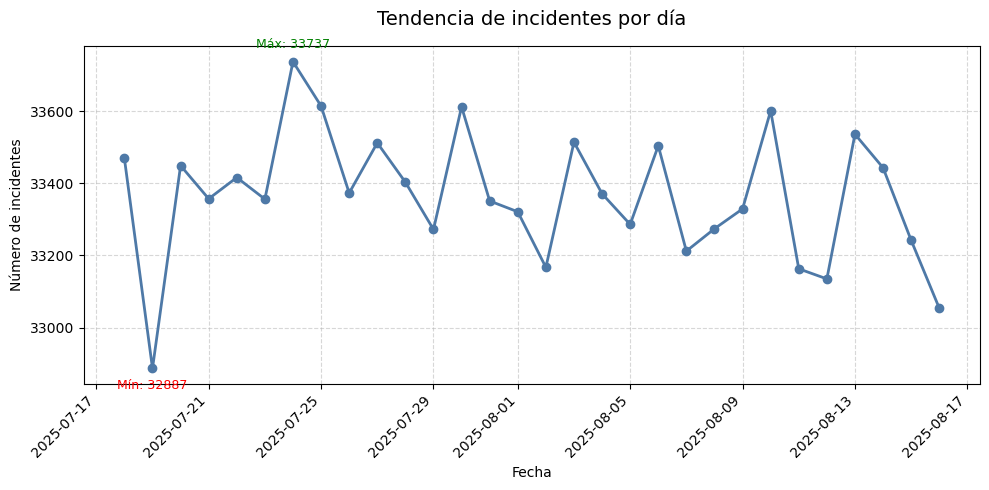

In [41]:
if 'fecha_reporte' in df.columns:
    ts = (
        pd.to_datetime(df['fecha_reporte'])
        .dt.date.value_counts()
        .sort_index()
    )
    
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(ts.index, ts.values, marker='o', linewidth=2, color="#4e79a7")
    
    # Títulos y etiquetas
    ax.set_title("Tendencia de incidentes por día", fontsize=14, pad=15)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Número de incidentes")
    
    # Formato del eje X (fechas)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    
    # Grid sutil
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Etiquetas en el punto máximo y mínimo
    max_idx = ts.values.argmax()
    min_idx = ts.values.argmin()
    ax.annotate(f'Máx: {ts.values[max_idx]}', 
                xy=(ts.index[max_idx], ts.values[max_idx]),
                xytext=(0,10), textcoords="offset points",
                ha='center', fontsize=9, color="green")
    ax.annotate(f'Mín: {ts.values[min_idx]}', 
                xy=(ts.index[min_idx], ts.values[min_idx]),
                xytext=(0,-15), textcoords="offset points",
                ha='center', fontsize=9, color="red")
    
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la columna 'fecha_reporte'.")


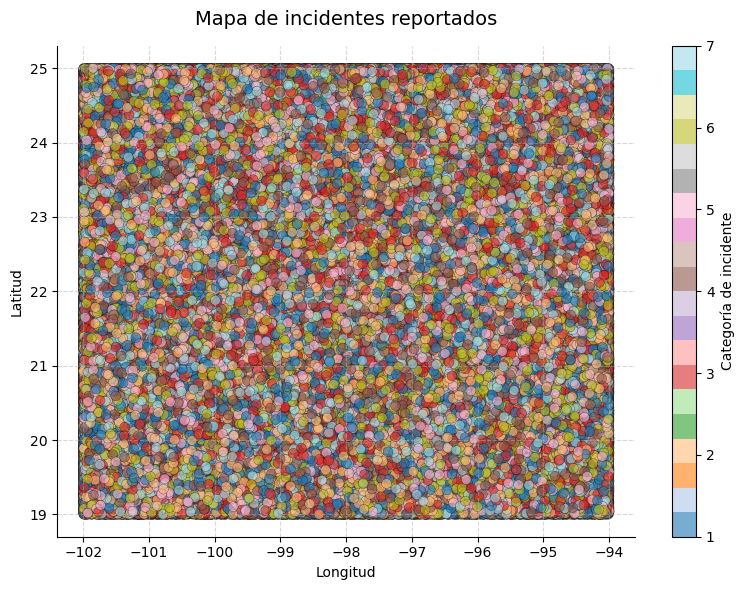

In [42]:
if {'latitud','longitud'}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(8,6))
    
    if 'categoria_id' in df.columns:
        scatter = ax.scatter(
            df['longitud'], df['latitud'],
            c=df['categoria_id'], cmap='tab20',
            alpha=0.6, s=50, edgecolors='k', linewidths=0.3
        )
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label("Categoría de incidente")
    else:
        ax.scatter(
            df['longitud'], df['latitud'],
            alpha=0.6, s=50, color="#4e79a7", edgecolors='k', linewidths=0.3
        )
    
    # Título y etiquetas
    ax.set_title("Mapa de incidentes reportados", fontsize=14, pad=15)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    
    # Estilo del grid
    ax.grid(True, linestyle="--", alpha=0.5)
    
    # Limpieza de spines
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay columnas de latitud/longitud.")

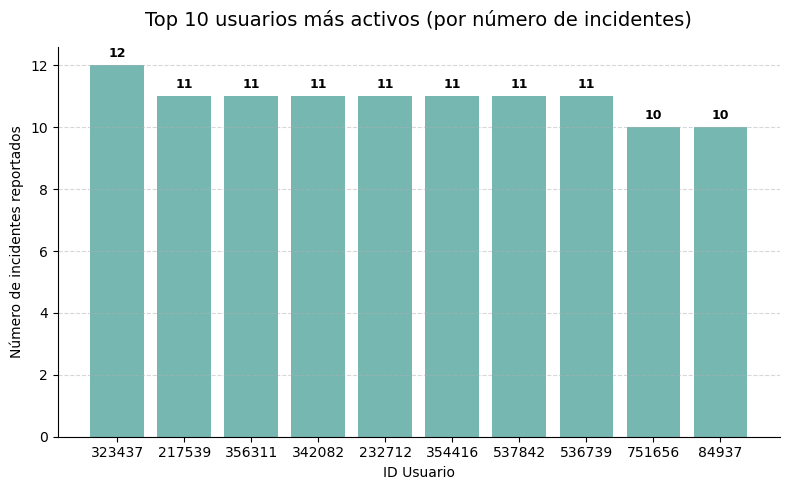

In [45]:
if 'usuario_id' in df.columns:
    top_users = (
        df.groupby('usuario_id')
        .size()
        .sort_values(ascending=False)
        .head(10)
    )
    
    fig, ax = plt.subplots(figsize=(8,5))
    bars = ax.bar(top_users.index.astype(str), top_users.values, color="#76b7b2")
    
    # Títulos y etiquetas
    ax.set_title("Top 10 usuarios más activos (por número de incidentes)", fontsize=14, pad=15)
    ax.set_xlabel("ID Usuario")
    ax.set_ylabel("Número de incidentes reportados")
    
    # Etiquetas de valores
    for bar in bars:
        height = bar.get_height()
        ax.annotate(str(height),
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight="bold")
    
    # Grid sutil
    ax.grid(axis='y', linestyle="--", alpha=0.5)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No existe la columna 'usuario_id' en el DataFrame.")


## 8) Exportación de Dataset Limpio

In [50]:
from sqlalchemy import text

with engine.begin() as conn:
    db_name = conn.execute(text("SELECT DATABASE()")).scalar()
    print("Conectado a la BD:", db_name)

    for t in ["usuarios","categorias","incidentes","comentarios"]:
        try:
            n = conn.execute(text(f"SELECT COUNT(*) FROM {t}")).scalar()
            print(f"Filas en {t}: {n}")
        except Exception as e:
            print(f"[AVISO] No pude consultar {t}: {e}")

Conectado a la BD: bd_alertaciudadana
Filas en usuarios: 1001000
Filas en categorias: 7
Filas en incidentes: 1001000
Filas en comentarios: 1001000


In [ ]:
from pathlib import Path

# si 'fecha_reporte' es datetime, dale formato legible antes:
if 'fecha_reporte' in df.columns:
    df['fecha_reporte'] = pd.to_datetime(df['fecha_reporte'])
    df['fecha_reporte'] = df['fecha_reporte'].dt.strftime('%d/%m/%Y %H:%M')

# limpia espacios raros
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

output_dir = Path("output"); output_dir.mkdir(exist_ok=True)
clean_path = output_dir / "incidentes_clean.csv"

df.to_csv(
    clean_path,
    index=False,
    encoding='utf-8-sig',
    sep=',',
)
print("Exportado:", clean_path)


## 9) Conclusión de esta Fase

- Se cargaron y consolidaron datos de **usuarios**, **categorías**, **incidentes** y **comentarios**.
- Se aplicó una limpieza básica (fechas, estados válidos, límites geográficos y duplicados).
- Se generaron visualizaciones iniciales para entender la distribución por categoría, estado, tiempo y ubicación.
- El dataset limpio se exportó a `output/incidentes_clean.csv` para su uso en fases posteriores (modelado supervisado/no supervisado o Data Warehouse).